# RQ4: Feature Importance Analysis

This section identifies the most important features influencing prediction using a Random Forest model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

In [6]:
df["Target"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

In [7]:
df = df.drop(columns=["Revenue_Generated"], errors='ignore')
df = df.fillna(df.mean(numeric_only=True))
df = pd.get_dummies(df, drop_first=True)

# reduce size
df = df.sample(2000, random_state=42)

In [8]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = RandomForestClassifier(n_estimators=50)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

In [10]:
importances = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [11]:
top_features = importance_df.sort_values(by="Importance", ascending=False).head(10)

top_features.to_csv("/kaggle/working/RQ4_table.csv", index=False)

top_features

,Feature,Importance
7,Bundle_Price,0.020952
0,Budget,0.019364
3,ROI,0.018690
1,Clicks,0.018489
6,Units_Sold,0.017837
2,Conversions,0.017836
5,Discount_Level,0.017715
4,Subscription_Length,0.014397
8,Customer_Satisfaction_Post_Refund,0.007295
30007,Subscription_Tier_Standard,0.003807


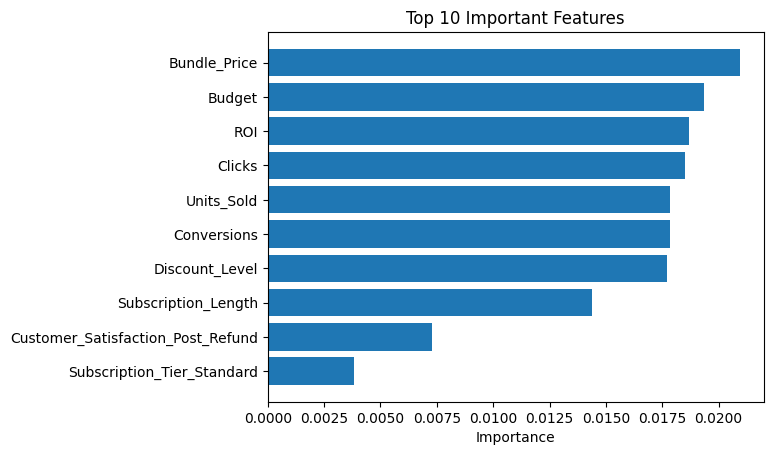

In [12]:
plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.savefig("/kaggle/working/RQ4_figure.pdf")

plt.gca().invert_yaxis()
plt.show()

## Results Interpretation

The results indicate that features such as Bundle Price, Budget, ROI, and Clicks have the highest importance in predicting customer revenue.

In [13]:
import os
os.listdir('/kaggle/working')

['.virtual_documents', 'RQ4_figure.pdf', 'RQ4_table.csv']